<a href="https://colab.research.google.com/github/yaj0212/Intermediate-Machine-Learning/blob/main/demos/smoothing/smoothing-demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Demo code for smoothing

This notebook illustrates the bias-variance tradeoff when trying to fit a curve to data, aka nonparametric regression.

We give simple, direct implementations of two algorithms. The first is called "kernel smoothing" and simply averages the $y$ values in the neighborhood of an $x$ value that we want to make a prediction for.  The second is very similar, but instead of just taking the average, we fit a line through those points.

As we average over smaller and smaller windows, the fitted function becomes more "wiggly." This corresponds to high variance, but low bias. Coversely, as we average over larger windows, the fitted function becomes smoother, but the squared bias increases. The "right" amount of smoothing will occur when the squared bias and the variance are roughly matched.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.animation as manim
from IPython.display import HTML, display

# jshtml embeds every frame as a base64 PNG in the notebook; raise the
# limit so larger animations (many bandwidths x many sampled trials)
# don't get silently dropped with a warning.
plt.rcParams['animation.embed_limit'] = 50  # MB


In [2]:
def kernel_smooth(X, y, x, h):
    K = np.zeros(len(x)*len(X)).reshape(len(x), len(X))
    for j in np.arange(K.shape[1]):
        K[:,j] = (1/h)*np.exp(-(x-X[j])**2/(2*h**2))
    fhat = np.dot(K, y) / np.sum(K, axis=1)
    return fhat

def true_fn(x):
    return 3*x**2

def build_kernel_animation(frames, x, f, sigma, interval_ms=150):
    """Build a FuncAnimation from precomputed frames instead of
    redrawing the whole figure per frame (which is what made the
    clear_output/sleep loop jumpy on Colab).

    frames: list of dicts with keys 'X', 'y', 'fhat', 'h'.
    interval_ms: delay between frames in milliseconds -- controls playback speed.
    """
    xx = np.linspace(-1, 1, 1000)
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x, f, color='red', linewidth=2, label='true function')
    line_est, = ax.plot([], [], color='blue', linewidth=2)
    line_kernel, = ax.plot([], [], color='gray', linewidth=1, label='smoothing kernel')
    scatter = ax.scatter([], [], color='black', alpha=.5, label='random sample')

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-2, np.max(f) + 6*sigma)
    ax.legend(loc='upper left')

    def update(i):
        d = frames[i]
        h = d['h']
        kernel = (1/h)*np.exp(-(xx**2)/(2*h**2))
        kernel = kernel/np.max(kernel) - 2

        line_est.set_data(x, d['fhat'])
        line_est.set_label('estimated function h=%.3f' % h)
        line_kernel.set_data(xx, kernel)
        scatter.set_offsets(np.column_stack([d['X'], d['y']]))
        ax.legend(loc='upper left')
        return line_est, line_kernel, scatter

    anim = manim.FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=False)
    plt.close(fig)
    return anim


In [3]:
min_x, max_x = -1, 1

x = np.linspace(min_x, max_x, 100)
f = true_fn(x)
sigma = .25
estimates = []
frames = []
bandwidths = [.3, .2, .1, .075, .05, .04, .02, .01, .009]
trials = 500

for h in bandwidths:
    estimates_h = []
    for i in np.arange(trials):
        X = np.sort(np.random.uniform(low=min_x, high=max_x, size=50))
        fX = true_fn(X)
        y = fX + sigma*np.random.normal(size=len(X))
        fhat = kernel_smooth(X, y, x, h=h)
        if i % 50 == 0:
            frames.append({'X': X, 'y': y, 'fhat': fhat, 'h': h})
        estimates_h.append(fhat)

    estimates.append(estimates_h)


/tmp/ipykernel_2966/2825984167.py:5: RuntimeWarning: invalid value encountered in divide
  fhat = np.dot(K, y) / np.sum(K, axis=1)


In [4]:
# Playback speed: milliseconds between frames. Lower = faster.
# Re-run just this cell to change speed without regenerating the data above.
interval_ms = 200

anim = build_kernel_animation(frames, x, f, sigma, interval_ms=interval_ms)
display(HTML(anim.to_jshtml()))


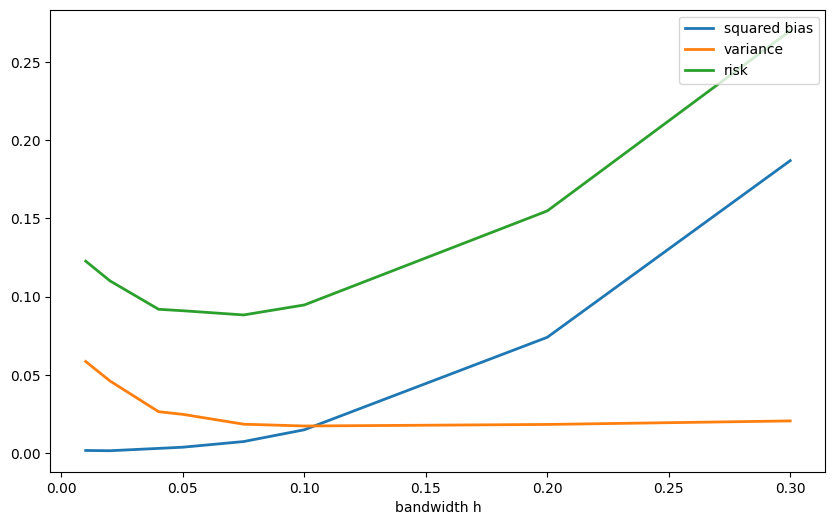

In [5]:
fhat = np.array(estimates)
sq_bias = np.zeros(len(bandwidths))
variance = np.zeros(len(bandwidths))

for i in np.arange(len(bandwidths)):
    sq_bias[i] = np.mean((np.mean(fhat[i], axis=0) - f)**2)
    variance[i] = np.mean(np.var(fhat[i], axis=0))

plt.figure(figsize=(10,6))
plt.plot(bandwidths, sq_bias, label='squared bias', linewidth=2)
plt.plot(bandwidths, variance, label='variance', linewidth=2)
plt.plot(bandwidths, sq_bias + variance + sigma**2, label='risk', linewidth=2)
plt.xlabel('bandwidth h')
plt.legend(loc='upper right')